# Day 09. Exercise 02
# Metrics

## 0. Imports

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score
import matplotlib.pyplot as plt
import joblib
import warnings

In [2]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
warnings.filterwarnings('ignore')

## 1. Preprocessing

1. Create the same dataframe as in the previous exercise.
2. Using `train_test_split` with parameters `test_size=0.2`, `random_state=21` get `X_train`, `y_train`, `X_test`, `y_test`. Use the additional parameter `stratify`.

In [3]:
df = pd.read_csv('../data/day-of-week-not-scaled.csv')
day_of_week = pd.read_csv('../data/dayofweek.csv', usecols=['dayofweek'])
df = pd.concat([day_of_week, df], axis=1)
df.head(1)

,dayofweek,numTrials,hour,uid_user_0,uid_user_1,uid_user_10,uid_user_11,uid_user_12,uid_user_13,uid_user_14,uid_user_15,uid_user_16,uid_user_17,uid_user_18,uid_user_19,uid_user_2,uid_user_20,uid_user_21,uid_user_22,uid_user_23,uid_user_24,uid_user_25,uid_user_26,uid_user_27,uid_user_28,uid_user_29,uid_user_3,uid_user_30,uid_user_31,uid_user_4,uid_user_6,uid_user_7,uid_user_8,labname_code_rvw,labname_lab02,labname_lab03,labname_lab03s,labname_lab05s,labname_laba04,labname_laba04s,labname_laba05,labname_laba06,labname_laba06s,labname_project1
0,4,1,5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [4]:
RANDOM_STATE=21
X = df.drop(columns=['dayofweek'])
y = df['dayofweek']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

## 2. SVM

1. Use the best parameters from the previous exercise and train the model of SVM.
2. You need to calculate `accuracy`, `precision`, `recall`, `ROC AUC`.

 - `precision` and `recall` should be calculated for each class (use `average='weighted'`)
 - `ROC AUC` should be calculated for each class against any other class (all possible pairwise combinations) and then weighted average should be applied for the final metric
 - the code in the cell should display the result as below:

```
accuracy is 0.88757
precision is 0.89267
recall is 0.88757
roc_auc is 0.97878
```

In [5]:
svc = SVC(
    C=10,
    class_weight=None,
    gamma='auto',
    kernel='rbf',
    random_state=RANDOM_STATE,
    probability=True
)

svc.fit(X_train, y_train)

SVC(C=10, gamma='auto', probability=True, random_state=21)

In [6]:
def print_metrics(model):
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)
    
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    roc_auc = roc_auc_score(y_test, y_pred_proba, multi_class='ovo', average='weighted')

    print(f'accuracy is {accuracy:.5}')
    print(f'precision is {precision:.5}')
    print(f'recall is {recall:.5}')
    print(f'roc_auc is {roc_auc:.5}')

In [7]:
print_metrics(svc)

accuracy is 0.88757
precision is 0.89267
recall is 0.88757
roc_auc is 0.97878


## 3. Decision tree

1. The same task for decision tree

In [8]:
tree = DecisionTreeClassifier(
    class_weight='balanced',
    criterion='gini',
    max_depth=21,
    random_state=RANDOM_STATE,
)

tree.fit(X_train, y_train)
print_metrics(tree)

accuracy is 0.88462
precision is 0.88765
recall is 0.88462
roc_auc is 0.93528


## 4. Random forest

1. The same task for random forest.

In [9]:
forest = RandomForestClassifier(
    class_weight='balanced',
    criterion='entropy',
    max_depth=24,
    n_estimators=100,
    random_state=RANDOM_STATE
)

forest.fit(X_train, y_train)
print_metrics(forest)

accuracy is 0.92604
precision is 0.92754
recall is 0.92604
roc_auc is 0.98939


## 5. Predictions

1. Choose the best model.
2. Analyze: for which `weekday` your model makes the most errors (in % of the total number of samples of that class in your full dataset), for which `labname` and for which `users`.
3. Save the model.

In [10]:
best_model = forest
y_pred_best = best_model.predict(X)

In [11]:
user_cols = [c for c in df.columns if c.startswith('uid_user_')]
labname_cols = [c for c in df.columns if c.startswith('labname_')]

df['user'] = df[user_cols].idxmax(axis=1)
df['labname'] = df[labname_cols].idxmax(axis=1)

errors = y.values != y_pred_best
error_idx = X.index[errors]

for col in ['dayofweek', 'labname', 'user']:
    err_counts = df.loc[error_idx, col].value_counts()
    total_counts = df[col].value_counts()
    rate = (err_counts / total_counts * 100).fillna(0)
    df[f'{col}_error_rate'] = df[col].map(rate).fillna(0)

In [12]:
weekday_summary = df[['dayofweek', 'dayofweek_error_rate']].drop_duplicates().sort_values('dayofweek_error_rate', ascending=False)
labname_summary = df[['labname', 'labname_error_rate']].drop_duplicates().sort_values('labname_error_rate', ascending=False)
user_summary = df[['user', 'user_error_rate']].drop_duplicates().sort_values('user_error_rate', ascending=False)

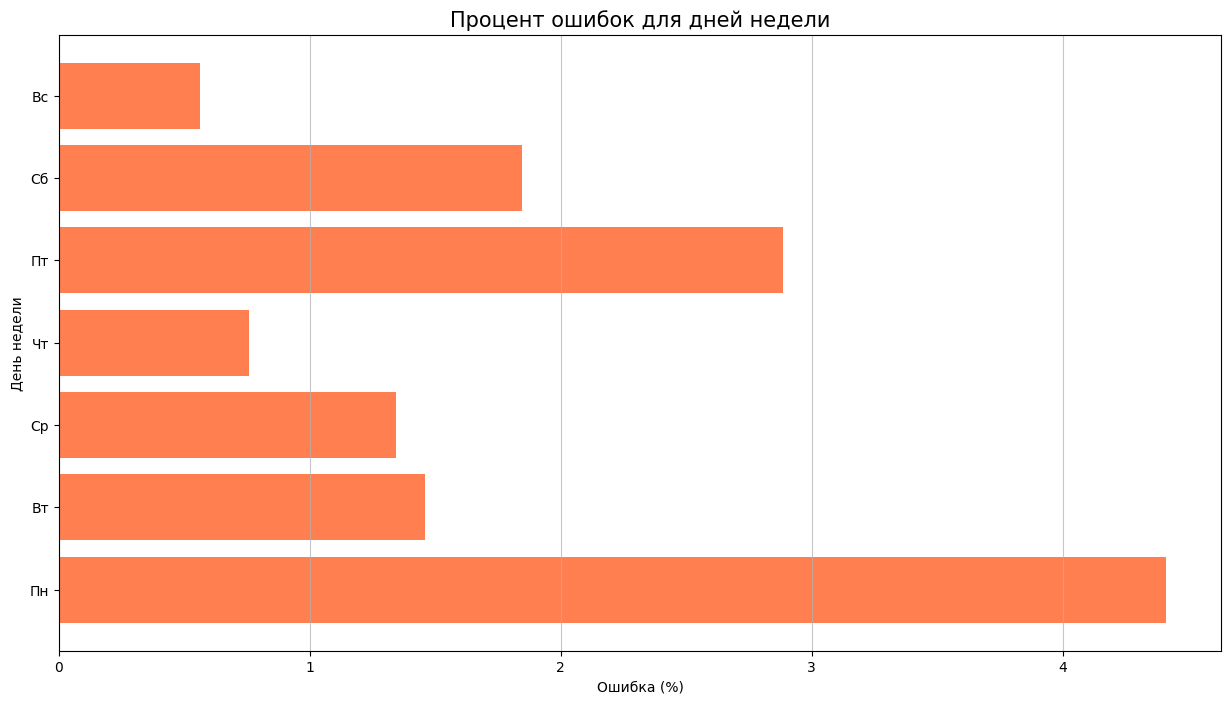

In [13]:
plt.figure(figsize=(15, 8))
plt.barh(
    weekday_summary['dayofweek'],
    weekday_summary['dayofweek_error_rate'],
    color='coral',
)
plt.grid(axis='x', alpha=0.7)
plt.xlabel('Ошибка (%)')
plt.ylabel('День недели')
plt.yticks(
    ticks=range(7),
    labels=['Пн', 'Вт', 'Ср', 'Чт', 'Пт', 'Сб', 'Вс'],
    fontsize=10
)
plt.title('Процент ошибок для дней недели', fontsize=15)
plt.show()

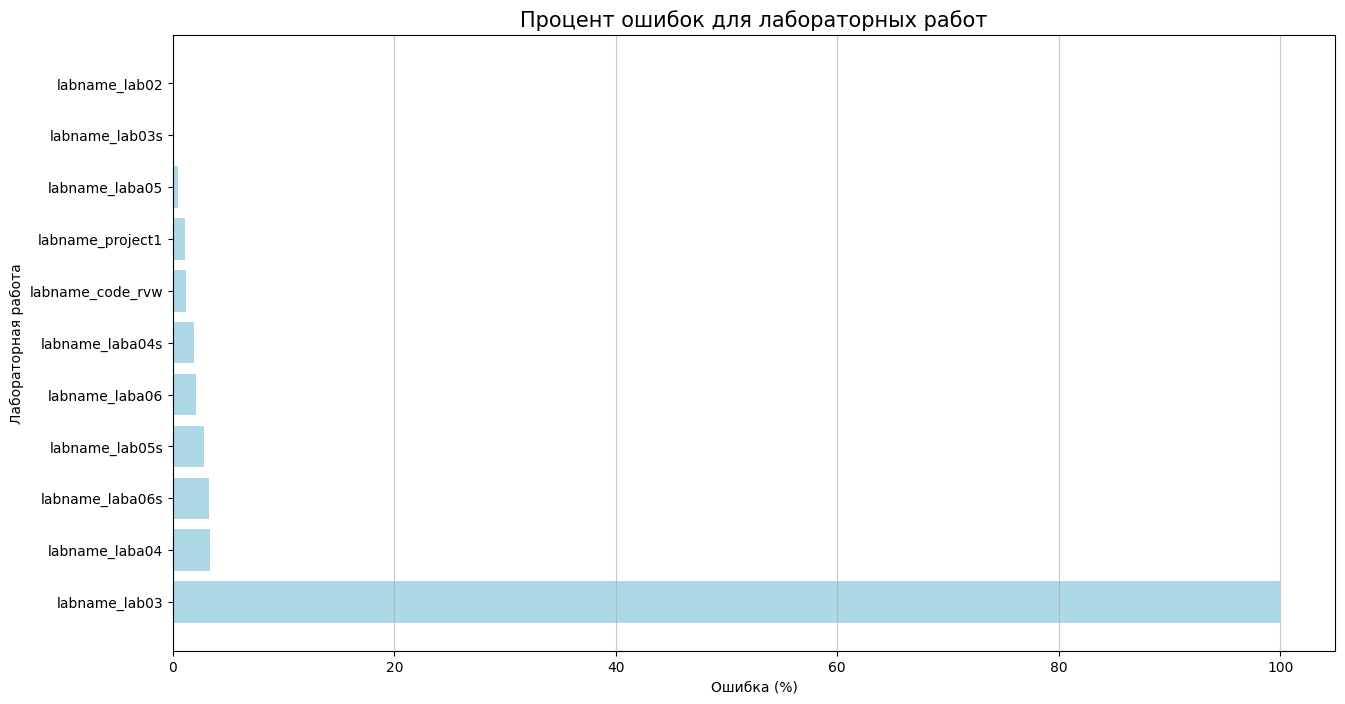

In [14]:
plt.figure(figsize=(15, 8))
plt.barh(
    labname_summary['labname'],
    labname_summary['labname_error_rate'],
    color='lightblue',
)
plt.grid(axis='x', alpha=0.7)
plt.xlabel('Ошибка (%)')
plt.ylabel('Лабораторная работа')
plt.title('Процент ошибок для лабораторных работ', fontsize=15)
plt.show()

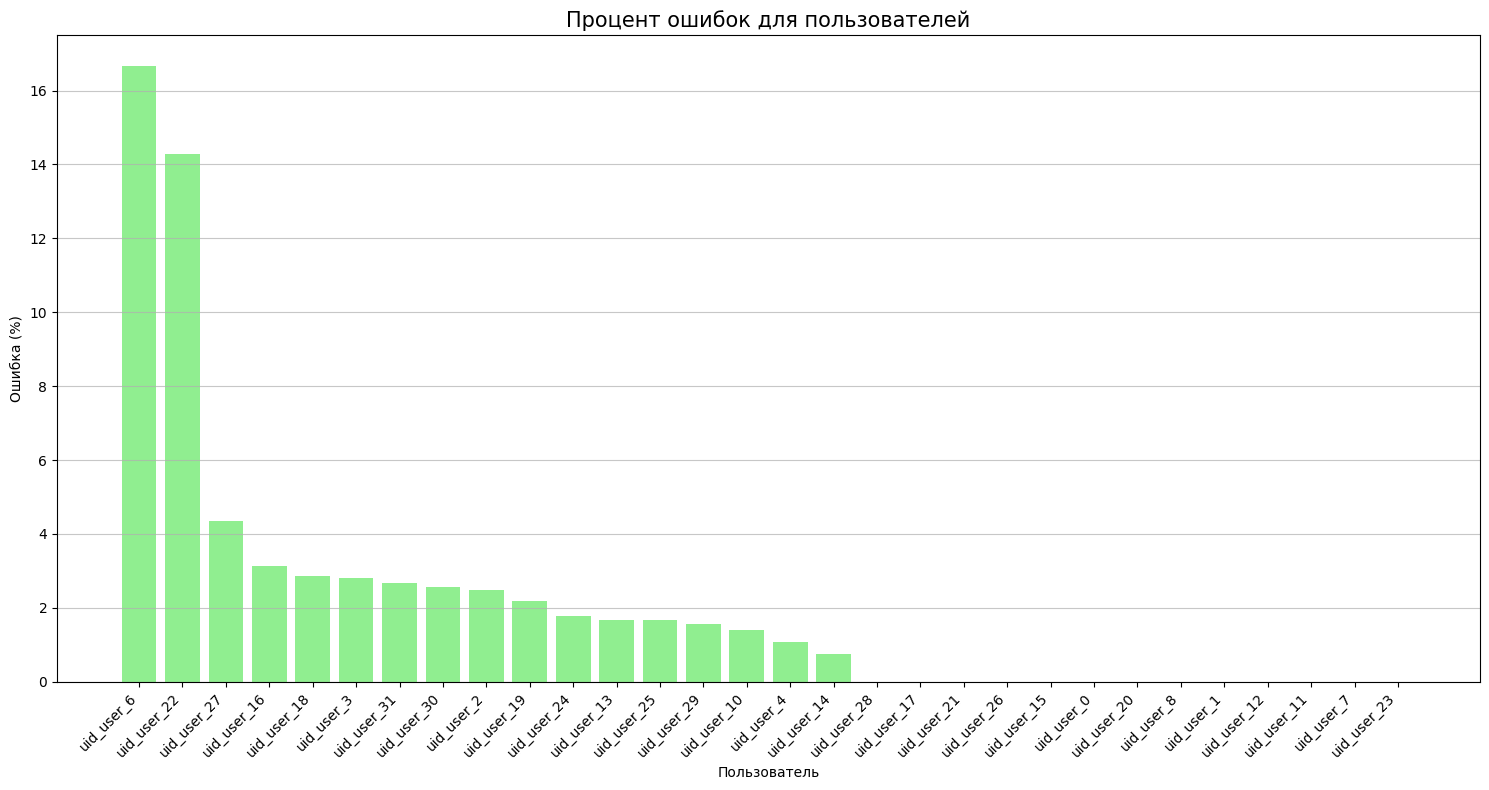

In [15]:
plt.figure(figsize=(15, 8))
plt.bar(
    user_summary['user'],
    user_summary['user_error_rate'],
    color='lightgreen'
)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.7) 
plt.xlabel('Пользователь')
plt.ylabel('Ошибка (%)')
plt.title('Процент ошибок для пользователей', fontsize=15)

plt.tight_layout()
plt.show()

**Выводы**: больше всего ошибок для понедельника (4.5%), модель не смогла сделать ни одного верного предсказания для lab03 (ошибка 100%), и хуже всего предсказывается user_6 (17% ошибок)

In [16]:
joblib.dump(best_model, '../data/ex02.pkl')

['../data/ex02.pkl']

## 6. Function

1. Write a function that takes a list of different models and a corresponding list of parameters (dicts) and returns a dict that contains all the 4 metrics for each model.

In [17]:
def evaluate_models(models, params_list):
    results = {}

    for model_class, params in zip(models, params_list):
        model = model_class(**params)
        model.fit(X_train, y_train)

        y_pred = model.predict(X_test)
        y_pred_proba = model.predict_proba(X_test)

        results[model_class.__name__] = {
            'accuracy': round(accuracy_score(y_test, y_pred), 5),
            'precision': round(precision_score(y_test, y_pred, average='weighted'), 5),
            'recall': round(recall_score(y_test, y_pred, average='weighted'), 5),
            'roc_auc': round(float(roc_auc_score(y_test, y_pred_proba, multi_class='ovo', average='weighted')), 5)
        }

    return results

In [18]:
models = [SVC, DecisionTreeClassifier, RandomForestClassifier]

params_list = [
    {'C': 10, 'class_weight': None, 'gamma': 'auto', 'kernel': 'rbf', 'random_state': RANDOM_STATE, 'probability': True},
    {'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': 21, 'random_state': RANDOM_STATE},
    {'class_weight': 'balanced', 'criterion': 'entropy', 'max_depth': 24, 'n_estimators': 100, 'random_state': RANDOM_STATE}
]

metrics_dict = evaluate_models(models, params_list)
metrics_dict

{'SVC': {'accuracy': 0.88757,
  'precision': 0.89267,
  'recall': 0.88757,
  'roc_auc': 0.97878},
 'DecisionTreeClassifier': {'accuracy': 0.88462,
  'precision': 0.88765,
  'recall': 0.88462,
  'roc_auc': 0.93528},
 'RandomForestClassifier': {'accuracy': 0.92604,
  'precision': 0.92754,
  'recall': 0.92604,
  'roc_auc': 0.98939}}